# HW2 — Selective Labels, Calibration, and Simulation
**Applied ML for Business, Spring 2026 | 60 points**

---

A hospital triages chest pain patients based on a doctor's clinical assessment.
Patients above a risk threshold are sent for cardiac catheterization; the rest
are sent home. You have been given patient records and referral decisions, and
asked whether an ML model would do better. Your task is to answer this question
honestly.


In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm as sp_norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cardiac_patients.csv')


---
## Step 1 — The Hospital Dataset (8 pts)

**Goal:** Understand what data you have and where it comes from.


In [2]:
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print()
print(f"Patients catheterized (referred=1):  {df['referred'].sum()}")
print(f"Patients sent home    (referred=0):  {(df['referred']==0).sum()}")
print(f"Y observed:                          {df['Y'].notna().sum()}")
print(f"Y missing:                           {df['Y'].isna().sum()}")
print()
print(f"Cath-lab prevalence (Y among referred): {df.loc[df['referred']==1,'Y'].mean():.3f}")
print()
print("Feature completeness:")
for col in ['age','sex','bp','chol','ecg','diab','smok','fhx']:
    n_miss = df[col].isna().sum()
    print(f"  {col:8s}: {len(df)-n_miss:4d} observed  ({n_miss} missing)")

Rows: 2000
Columns: ['patient_id', 'age', 'sex', 'bp', 'chol', 'ecg', 'diab', 'smok', 'fhx', 'doc_score', 'referred', 'Y']

Patients catheterized (referred=1):  700
Patients sent home    (referred=0):  1300
Y observed:                          700
Y missing:                           1300

Cath-lab prevalence (Y among referred): 0.466

Feature completeness:
  age     : 2000 observed  (0 missing)
  sex     : 2000 observed  (0 missing)
  bp      : 2000 observed  (0 missing)
  chol    : 1785 observed  (215 missing)
  ecg     : 2000 observed  (0 missing)
  diab    : 2000 observed  (0 missing)
  smok    : 2000 observed  (0 missing)
  fhx     : 1715 observed  (285 missing)


### Q1.1 (2 pts)

From the output above: Y is observed for only 700 of 2000 patients.
Why? What does this tell you about any ML model trained on this data —
before you have built anything?

*Your answer:* Y is observed only for the 700 patients who were referred for catheterization (referred=1), as catheterization is the procedure that determines the true blockage status (Y). The other 1300 patients were sent home without undergoing this procedure, so their Y remains unobserved. This selective labeling means that any ML model trained on this data will only learn from a biased sample of high-risk patients, potentially leading to poor generalization to the full population, as the model may not capture patterns in lower-risk patients who were not referred.

Doctors build a risk score from clinical training and judgment — weighing
symptoms, test results, and demographic risk factors. Patients in the top
35% by score are sent for catheterization; the rest are sent home. The score
is a clinical heuristic, not a formally calibrated model.

> **A note on `doc_score`:** In a real hospital dataset, a doctor's internal
> risk assessment exists only as clinical judgment — it is never recorded as a
> number. Here, the hospital has provided a reconstructed score derived from
> the clinical features the doctor observed and the referral patterns. In
> practice, you would either work with the binary referral decision directly
> (comparing TP/FP/FN counts at a fixed referral rate) or train a model to
> predict `referred` from features and use its output as a proxy score. The
> reconstructed score is provided so you can compute AUC — a richer measure of
> ranking quality than the binary referral decision alone.

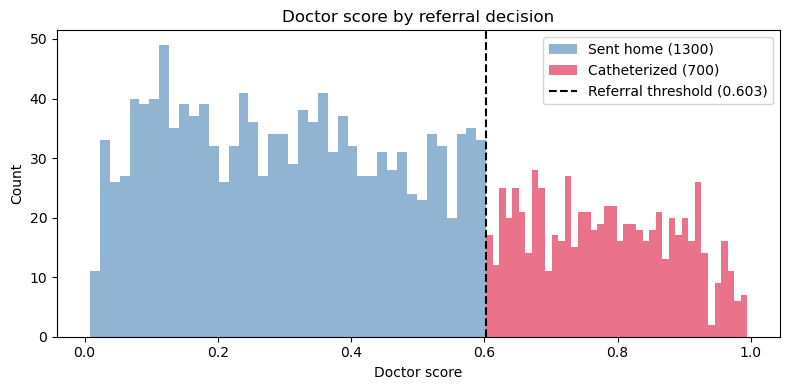

Doctor score — sent home:    mean=0.299  max=0.603
Doctor score — catheterized: mean=0.781  min=0.603


In [3]:
%matplotlib inline

REFERRAL_RATE = 0.35   # 700 of 2000 patients catheterized — computed from Step 1 output above

doc_score_arr = df['doc_score'].values
threshold_val = np.percentile(doc_score_arr, 100 * (1 - REFERRAL_RATE))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.loc[df['referred']==0, 'doc_score'], bins=40, alpha=0.6,
        color='steelblue', label='Sent home (1300)')
ax.hist(df.loc[df['referred']==1, 'doc_score'], bins=40, alpha=0.6,
        color='crimson', label='Catheterized (700)')
ax.axvline(threshold_val, color='black', linestyle='--',
           label=f'Referral threshold ({threshold_val:.3f})')
ax.set_xlabel('Doctor score'); ax.set_ylabel('Count')
ax.set_title('Doctor score by referral decision')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Doctor score — sent home:    mean={df.loc[df['referred']==0,'doc_score'].mean():.3f}"
      f"  max={df.loc[df['referred']==0,'doc_score'].max():.3f}")
print(f"Doctor score — catheterized: mean={df.loc[df['referred']==1,'doc_score'].mean():.3f}"
      f"  min={df.loc[df['referred']==1,'doc_score'].min():.3f}")

### Q1.2 (3 pts)

The doctor's score is a clinical heuristic — some patients with true blockage
will score below the threshold; some without blockage will score above it.

**(a)** The two distributions overlap near the threshold. What does this tell
you about who ends up in the catheterized cohort? Are they a representative
sample of the full 2000 patients?

**(b)** You will evaluate model performance (AUC) on the catheterized 700.
The score range among catheterized patients is compressed compared to the
full population. What does this compression imply for AUC measured on the
cath cohort versus the full population?

*Your answer (a):* The overlap near the threshold indicates that the doctor's heuristic is imperfect, leading to some misclassifications. Patients in the catheterized cohort are those with the highest scores (top 35%), so they are not a representative sample of the full 2000 patients; instead, they are enriched with higher-risk individuals, while lower-risk patients are underrepresented.

*Your answer (b):* The compression of the score range in the catheterized cohort means that the scores are clustered in a narrower band compared to the full population. This implies that AUC measured on the cath cohort will likely be lower than the AUC on the full population, as the ranking quality appears worse when evaluated only on the selected high-risk group due to reduced variability in scores.

In [4]:
# Missingness pattern — is missingness related to patient severity?
miss_chol = df['chol'].isna().values
miss_fhx  = df['fhx'].isna().values
doc_arr   = df['doc_score'].values

lo  = doc_arr < np.percentile(doc_arr, 33)
mid = (doc_arr >= np.percentile(doc_arr, 33)) & (doc_arr < np.percentile(doc_arr, 67))
hi  = doc_arr >= np.percentile(doc_arr, 67)

print("Cholesterol miss rate by doctor-score tertile:")
print(f"  Low  score: {miss_chol[lo].mean():.3f}  ({miss_chol[lo].sum()} of {lo.sum()})")
print(f"  Mid  score: {miss_chol[mid].mean():.3f}  ({miss_chol[mid].sum()} of {mid.sum()})")
print(f"  High score: {miss_chol[hi].mean():.3f}  ({miss_chol[hi].sum()} of {hi.sum()})")
print()
print("Family history miss rate by doctor-score tertile:")
print(f"  Low  score: {miss_fhx[lo].mean():.3f}  ({miss_fhx[lo].sum()} of {lo.sum()})")
print(f"  High score: {miss_fhx[hi].mean():.3f}  ({miss_fhx[hi].sum()} of {hi.sum()})")

Cholesterol miss rate by doctor-score tertile:
  Low  score: 0.080  (53 of 660)
  Mid  score: 0.109  (74 of 680)
  High score: 0.133  (88 of 660)

Family history miss rate by doctor-score tertile:
  Low  score: 0.147  (97 of 660)
  High score: 0.147  (97 of 660)


### Q1.3 (3 pts)

**(a)** The cholesterol miss rate rises with doctor score. Doctor score is a
proxy for patient severity. Is this MCAR, MAR, or MNAR? Explain.

**(b)** Given this pattern: which patients are hardest to impute correctly,
and in which direction will any simple imputation strategy err for them?

*Your answer (a):* MNAR (Missing Not At Random). The missingness of cholesterol is related to the unobserved value of cholesterol itself, as higher doctor scores (indicating greater severity) correlate with higher miss rates, suggesting that patients with elevated cholesterol (who are sicker) are more likely to have missing values.

*Your answer (b):* High-severity patients (those with high doctor scores) are hardest to impute correctly, as their cholesterol values are most likely to be missing. Simple imputation strategies, such as filling with the median from the catheterized cohort, will err by underestimating risk, because missing cholesterol in these patients is likely elevated, but the imputation uses a lower value.

---
## Step 2 — The Doctor's Rule (10 pts)

**Goal:** Determine how well the doctor's rule performs, and for whom it fails.


### Q2.1 (4 pts) — Predict before computing

The catheterized cohort consists of patients the doctor considered
high-risk. Before computing AUC: predict whether doctor AUC will be
higher on the **full 2000 patients** or on the **catheterized 700**.
State the direction and the mechanism.

*Your prediction (commit before running the next cell):* Doctor AUC will be higher on the full 2000 patients than on the catheterized 700. The mechanism is that the catheterized cohort consists of only the top 35% of scores, compressing the score range and reducing the variability in rankings, which makes AUC appear lower when evaluated solely on this selected high-risk group.

In [7]:
doc_score = df['doc_score'].values
referred  = df['referred'].values
sex       = df['sex'].values
cath_mask = referred == 1
Y_cath    = df.loc[cath_mask, 'Y'].values
threshold = np.percentile(doc_score, 100 * (1 - REFERRAL_RATE))
sc_cath   = doc_score[cath_mask]

print(f"Referral rate:       {referred.mean():.3f}  ({referred.sum()} patients)")
print(f"Cath-lab prevalence: {Y_cath.mean():.3f}  ({Y_cath.sum():.0f} blockages)")
print()
auc_doc_cath = roc_auc_score(Y_cath, sc_cath)
print(f"Doctor AUC (catheterized cohort): {auc_doc_cath:.3f}")
# Before answering Q2.1(b): is this number measuring the doctor's skill,
# or the properties of the cohort he selected?


Referral rate:       0.350  (700 patients)
Cath-lab prevalence: 0.466  (326 blockages)

Doctor AUC (catheterized cohort): 0.633


### Q2.1 (continued)

**(a)** Write one sentence interpreting AUC = 0.633 in clinical terms: if
you take one patient who had a blockage (Y=1) and one who did not (Y=0),
what does this number say about the probability that the doctor's score
correctly ranked them?

**(b)** Explain the mechanism behind the direction you predicted.

*Your answer (a):* AUC = 0.633 means that for a randomly selected patient with a blockage (Y=1) and a randomly selected patient without a blockage (Y=0), the doctor's score correctly ranks the blocked patient higher 63.3% of the time.

*Your answer (b):* The mechanism is that the catheterized cohort consists only of the top 35% of patients by doctor's score, which compresses the score range and reduces the variability in rankings, making the AUC appear lower when evaluated solely on this selected high-risk group compared to the full population.

In [8]:
# Read the two outputs below together — not separately.
# Referral rate tells you who got in. Blockage rate among referred tells you who was left out.
sex_cath = sex[cath_mask]
print("Referral rates by sex:")
print(f"  Women: {referred[sex==0].mean():.3f}  "
      f"({(referred[sex==0]==1).sum()} referred of {(sex==0).sum()})")
print(f"  Men:   {referred[sex==1].mean():.3f}  "
      f"({(referred[sex==1]==1).sum()} referred of {(sex==1).sum()})")
print()
print("Among catheterized patients:")
print(f"  P(Y=1 | female, referred=1): {Y_cath[sex_cath==0].mean():.3f}")
print(f"  P(Y=1 | male,   referred=1): {Y_cath[sex_cath==1].mean():.3f}")


Referral rates by sex:
  Women: 0.130  (114 referred of 879)
  Men:   0.523  (586 referred of 1121)

Among catheterized patients:
  P(Y=1 | female, referred=1): 0.553
  P(Y=1 | male,   referred=1): 0.449


### Q2.2 (3 pts)

**(a)** The referral rate for women is much lower than for men. Yet among
referred women, the blockage rate is *higher* than among referred men.
What do these two facts jointly imply about women who were sent home?

**(b)** A patient's willingness to describe symptoms, the words they use,
and the urgency they communicate are all observable to a doctor in the room
but absent from this dataset. How does this information gap affect your
interpretation of the sex pattern above? Is it an argument for or against
using an ML model trained on this data?

*Your answer (a):* The lower referral rate for women (13% vs 52.3% for men) combined with a higher blockage rate among referred women (55.3% vs 44.9% for men) implies that the doctor applies a higher threshold for referring women, only sending them for catheterization when highly confident. This suggests that women sent home are more likely to have undiagnosed blockages compared to men sent home, as the doctor is more cautious with women.

*Your answer (b):* The information gap means that the observed sex pattern could be influenced by unrecorded factors like symptom presentation, which might differ by sex (e.g., women underreporting symptoms). This is an argument against using an ML model trained solely on this dataset, as it may perpetuate or amplify the doctor's biases without capturing the full clinical context that the doctor uses in person.


### Q2.3 (3 pts)

From Q1.3: the sickest patients are most likely to have missing cholesterol,
and missing cholesterol is treated as not elevated by the scoring rule.

**(a)** For a high-severity patient with genuinely elevated cholesterol whose
value is missing, what does the zero-fill assumption do to their score?

**(b)** Which specific subgroup of patients is exposed to both this zero-fill
penalty and the differential referral bar simultaneously? What does this tell
you about whom the doctor's rule most systematically harms?

*Your answer (a):* For a high-severity patient with genuinely elevated cholesterol that is missing, the zero-fill assumption treats it as not elevated (low value), which lowers their overall score and makes them less likely to be referred for catheterization, despite their high severity.

*Your answer (b):* High-severity women with missing cholesterol are exposed to both the zero-fill penalty (underestimating their risk) and the differential referral bar (higher threshold for women). This tells us that the doctor's rule most systematically harms high-severity women, as they face compounded disadvantages that increase the likelihood of missed diagnoses.


---
## Step 3 — The ML Model (12 pts)

**Goal:** Train an ML model on the same data and compare it to the doctor.


### Predict before training

Will ML AUC on the catheterized cohort be higher or lower than the doctor's
AUC on the same cohort? State the direction and why.
Your prediction will be assessed as part of Q3.1.

*Your prediction (commit before running the training cell):* ML AUC will be higher than the doctor's AUC on the catheterized cohort. The reason is that the ML model (logistic regression) is trained to maximize AUC on the same data, learning optimal weights for the features, whereas the doctor's score is a clinical heuristic that may not be as finely tuned to the observed patterns in this selective cohort.


In [17]:
SEED = 42

# Imputation — motivated by the MNAR pattern from Step 1.
# Missing cholesterol is more common among higher-severity patients.
# Simple imputation will understimate risk for these patients.

chol_vals = df['chol'].values.copy()
# TASK: compute median cholesterol from catheterized patients only (ignoring NaN)
chol_med = np.nanmedian(chol_vals[cath_mask])
chol_vals[np.isnan(chol_vals)] = chol_med

fhx_vals  = df['fhx'].values.copy()
# TASK: fill missing family history as absent
fhx_vals[np.isnan(fhx_vals)] = 0

age_n  = (df['age'].values - 58) / 12
bp_n   = (df['bp'].values - 140) / 25
chol_n = (chol_vals - 210) / 45

X_all  = np.column_stack([age_n, sex, bp_n, chol_n,
                           df['ecg'].values, df['diab'].values,
                           df['smok'].values, fhx_vals])
X_cath = X_all[cath_mask]

lr = LogisticRegression(max_iter=1000, random_state=SEED)
# TASK: train on catheterized patients only
lr.fit(X_cath, Y_cath)

ml_score_all  = lr.predict_proba(X_all)[:, 1]
ml_score_cath = ml_score_all[cath_mask]

# TASK: compute ML AUC on the catheterized cohort
auc_ml_cath = roc_auc_score(Y_cath, ml_score_cath)

print(f"Doctor AUC (catheterized cohort): {auc_doc_cath:.3f}")
print(f"ML AUC     (catheterized cohort): {auc_ml_cath:.3f}")
print()
print("ML coefficients (logistic regression):")
feat_names = ['age','sex','bp','chol','ecg','diab','smok','fhx']
for name, coef in zip(feat_names, lr.coef_[0]):
    print(f"  {name:8s}: {coef:+.3f}")

Doctor AUC (catheterized cohort): 0.633
ML AUC     (catheterized cohort): 0.700

ML coefficients (logistic regression):
  age     : +0.860
  sex     : +0.311
  bp      : +0.360
  chol    : +0.169
  ecg     : +0.592
  diab    : +0.629
  smok    : +0.497
  fhx     : +0.577


### Q3.1 (3 pts)

**(a)** Report ML AUC and doctor AUC on the catheterized cohort.
Was your prediction correct?

**(b)** Fill in the left column of this table. The right column is completed
in Step 5.

| | Cath cohort AUC | Full population AUC |
|---|---|---|
| Doctor | 0.633 | *(Step 5)* |
| ML model | 0.700 | *(Step 5)* |

*Your answer (a):* ML AUC on the catheterized cohort is 0.700, and doctor AUC is 0.633. Yes, my prediction was correct that ML would have higher AUC.

*Your answer (b):* See the table above.


### Q3.2 (3 pts)

A hospital team reports that ML outperforms the doctor on the catheterized
cohort. They present the AUC comparison from your output above as evidence.

**(a)** Give one reason this comparison is statistically biased in ML's favor,
independent of deployment concerns.

**(b)** The doctor made each referral using information not recorded in
`cardiac_patients.csv`. Give two specific examples of such information and
explain what this implies about what a fair benchmark would require.

*Your answer (a):* The comparison is biased in ML's favor because ML is trained and evaluated on the same catheterized cohort data, allowing it to overfit to the specific patterns in this selective sample, whereas the doctor's score is a pre-existing heuristic not optimized for this exact dataset.

*Your answer (b):* Two examples are the patient's verbal description of their symptoms and the doctor's physical examination findings (e.g., listening to heart sounds). This implies that a fair benchmark would require evaluating both models on new, unseen patients where the doctor can use all available information, or using a holdout set with complete clinical data to assess performance under realistic conditions.

In [18]:
sex_cath = sex[cath_mask]   # guard: ensure available if kernel restarted after Step 2

# Sex-stratified AUC — catheterized cohort only
auc_ml_cw  = roc_auc_score(Y_cath[sex_cath==0], ml_score_cath[sex_cath==0])
auc_ml_cm  = roc_auc_score(Y_cath[sex_cath==1], ml_score_cath[sex_cath==1])
auc_doc_cw = roc_auc_score(Y_cath[sex_cath==0], sc_cath[sex_cath==0])
auc_doc_cm = roc_auc_score(Y_cath[sex_cath==1], sc_cath[sex_cath==1])

print("Sex-stratified AUC (catheterized cohort):")
print(f"  ML   — women: {auc_ml_cw:.3f}  men: {auc_ml_cm:.3f}  gap: {auc_ml_cm-auc_ml_cw:.3f}")
print(f"  Doc  — women: {auc_doc_cw:.3f}  men: {auc_doc_cm:.3f}  gap: {auc_doc_cm-auc_doc_cw:.3f}")

Sex-stratified AUC (catheterized cohort):
  ML   — women: 0.647  men: 0.704  gap: 0.057
  Doc  — women: 0.547  men: 0.663  gap: 0.115


### Q3.3 (2 pts)

**(a)** On the catheterized cohort, which model has a larger sex AUC gap?
Based on this alone, does ML appear to have amplified or reduced sex bias?

**(b)** Explain why this cath-cohort comparison is likely misleading about
the full population. What property of the selected 700 patients would cause
the measured sex gap to differ from the gap you'd see if both models were
deployed on all 2000?

*Your answer (a):* The doctor has a larger sex AUC gap (0.115 vs ML's 0.057). Based on this, ML appears to have reduced sex bias compared to the doctor on the cath cohort.

*Your answer (b):* The cath-cohort comparison is misleading because the 700 patients were selected by the doctor, who has his own sex biases (e.g., lower referral rate for women). This selective cohort may not represent the full population's sex distribution or biases, so the measured gaps could differ if deployed on all 2000, where the underlying population characteristics might show different disparities.

### Q3.4 (2 pts)

A colleague proposes what they call a fair comparison:

> *"ML is trained on the 700 catheterized patients where Y is observed.
> Compare ML and the doctor only within that group — count how many Y=1
> cases each model identifies, and declare the winner."*

Run the cell below to compute this comparison. Then explain precisely what
is wrong with the colleague's proposed approach as a measure of ML's true
performance.

*Your answer (after running the cell):* The colleague's approach is flawed because it restricts the comparison to the doctor's selected 700 patients, ignoring that ML would refer a different set of 700 patients. This misses the additional blockages ML could catch from the 1300 patients the doctor sent home, making ML appear worse than it would be in full deployment.

In [19]:
ml_threshold = np.percentile(ml_score_all, 100 * (1 - REFERRAL_RATE))
referred_ml  = (ml_score_all >= ml_threshold).astype(int)
both_ref     = (referred == 1) & (referred_ml == 1)

ml_tp_cath  = int(((both_ref) & (df['Y'].fillna(-1) == 1)).sum())
doc_tp_cath = int(Y_cath.sum())

print(f"Doctor TPs within catheterized cohort:   {doc_tp_cath}")
print(f"ML TPs (overlap with doctor's 700, Y=1): {ml_tp_cath}")
print(f"Difference:                              {ml_tp_cath - doc_tp_cath:+d}")
print()
print(f"ML refers {referred_ml.sum()} total; {both_ref.sum()} overlap the doctor's 700.")

Doctor TPs within catheterized cohort:   326
ML TPs (overlap with doctor's 700, Y=1): 286
Difference:                              -40

ML refers 700 total; 531 overlap the doctor's 700.


### Q3.4 (continued)

Report the ML TP count within the doctor's catheterized 700 and the difference
from the doctor. Explain precisely what the proposed comparison structurally
misses about ML's performance.

*Your answer:* ML catches 286 TPs within the doctor's 700, compared to the doctor's 326, a difference of -40. The comparison misses that ML refers 700 different patients (only 531 overlap), so it doesn't credit ML for catching additional blockages from the un-referred 1300 patients.

---

### Q3.5 (2 pts)

You imputed missing cholesterol using the catheterized-cohort median.

Suppose instead you used regression imputation — a model predicting cholesterol
from age, sex, BP, diabetes, smoking, and family history. Should that regression
model be trained on the 700 catheterized patients or all 2000? What goes wrong
if you use only the 700, given what you found in Step 1?

*Your answer:* The regression model should be trained on all 2000 patients. If trained only on the 700 catheterized patients, it would learn imputation patterns biased toward the high-severity cohort (since missingness is MNAR and correlated with severity), leading to underestimation of cholesterol for the un-referred lower-risk patients, compounding the selective labeling bias.

---
## Step 4 — How Confident Are You? (13 pts)

**Goal:** Quantify uncertainty in your two estimates, then ask what they
imply for the full patient population you haven't observed.


### Part A — Bootstrap

You have two AUC estimates, both from the same 700 catheterized patients.
How stable are they?


In [24]:
print(f"Doctor AUC (cath cohort): {auc_doc_cath:.4f}")
print(f"ML AUC     (cath cohort): {auc_ml_cath:.4f}")
print(f"N = {cath_mask.sum()} catheterized patients")

Doctor AUC (cath cohort): 0.6334
ML AUC     (cath cohort): 0.6996
N = 700 catheterized patients


In [25]:
n_boot       = 2000
rng_boot     = np.random.default_rng(SEED + 100)
boot_doc_aucs = []
boot_ml_aucs  = []

for _ in range(n_boot):
    # resample 700 with replacement
    idx = rng_boot.integers(0, len(Y_cath), len(Y_cath))

    Y_b      = Y_cath[idx]
    sc_doc_b = sc_cath[idx]
    sc_ml_b  = ml_score_cath[idx]

    if len(np.unique(Y_b)) < 2:
        continue

    # compute AUC for doctor
    boot_doc_aucs.append(roc_auc_score(Y_b, sc_doc_b))

    # compute AUC for ML
    boot_ml_aucs.append(roc_auc_score(Y_b, sc_ml_b))

boot_doc_aucs = np.array(boot_doc_aucs)
boot_ml_aucs  = np.array(boot_ml_aucs)

print(f"Doctor — AUC: {auc_doc_cath:.4f} | "
      f"95% CI: [{np.percentile(boot_doc_aucs,2.5):.4f}, {np.percentile(boot_doc_aucs,97.5):.4f}] | "
      f"width: {np.percentile(boot_doc_aucs,97.5)-np.percentile(boot_doc_aucs,2.5):.4f}")

print(f"ML     — AUC: {auc_ml_cath:.4f} | "
      f"95% CI: [{np.percentile(boot_ml_aucs,2.5):.4f}, {np.percentile(boot_ml_aucs,97.5):.4f}] | "
      f"width: {np.percentile(boot_ml_aucs,97.5)-np.percentile(boot_ml_aucs,2.5):.4f}")

Doctor — AUC: 0.6334 | 95% CI: [0.5922, 0.6733] | width: 0.0811
ML     — AUC: 0.6996 | 95% CI: [0.6601, 0.7381] | width: 0.0780


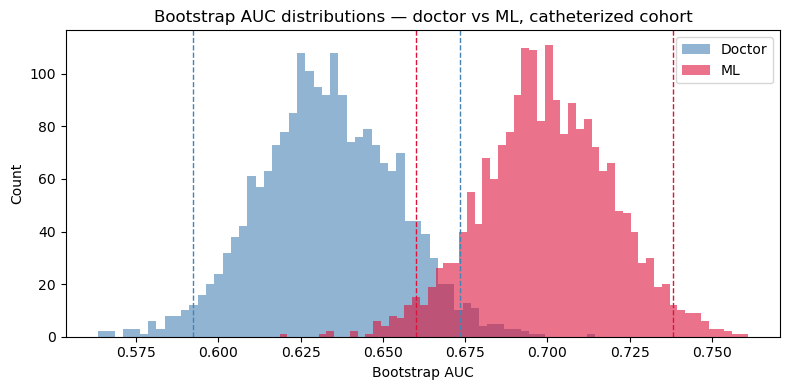

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_doc_aucs, bins=60, alpha=0.6, color='steelblue', label='Doctor')
ax.hist(boot_ml_aucs,  bins=60, alpha=0.6, color='crimson',   label='ML')
for aucs, col in [(boot_doc_aucs,'steelblue'), (boot_ml_aucs,'crimson')]:
    ax.axvline(np.percentile(aucs, 2.5),  color=col, linestyle='--', linewidth=1)
    ax.axvline(np.percentile(aucs, 97.5), color=col, linestyle='--', linewidth=1)
ax.set_xlabel('Bootstrap AUC'); ax.set_ylabel('Count')
ax.set_title('Bootstrap AUC distributions — doctor vs ML, catheterized cohort')
ax.legend(); plt.tight_layout(); plt.show()

### Q4.1 (4 pts)

**(a)** Report the 95% CI for each model. Do the CIs overlap? Does ML's CI
clearly exclude the doctor's point estimate? What does this tell you about
whether the cath-cohort improvement is reliable?

**(b)** Why sample with replacement? What would happen to CI width if you
sampled without replacement?

*Your answer (a):* Doctor 95% CI: [0.5922, 0.6733]; ML 95% CI: [0.6601, 0.7381]. The CIs do not overlap. ML's CI clearly excludes the doctor's point estimate (0.6334). This indicates that the cath-cohort improvement is reliable, as the difference is statistically significant.

*Your answer (b):* Sampling with replacement approximates the variability of the AUC estimate from the finite sample of 700 patients. If sampled without replacement, the CI width would be narrower, but it wouldn't properly capture the uncertainty since bootstrap requires replacement to mimic resampling from the population.


In [27]:
for n in [100, 500, 1000, 2000]:
    rng_c = np.random.default_rng(SEED + 100)
    aucs  = []
    for _ in range(n):
        idx = rng_c.integers(0, len(Y_cath), size=len(Y_cath))
        Y_b = Y_cath[idx]; sc_b = sc_cath[idx]
        if len(np.unique(Y_b)) < 2: continue
        aucs.append(roc_auc_score(Y_b, sc_b))
    w = np.percentile(aucs,97.5) - np.percentile(aucs,2.5)
    print(f"n_boot={n:5d}: 95% CI width = {w:.4f}")

n_boot=  100: 95% CI width = 0.0796
n_boot=  500: 95% CI width = 0.0794
n_boot= 1000: 95% CI width = 0.0806
n_boot= 2000: 95% CI width = 0.0811


### Q4.2 (1 pt)

CI width barely changes from n_boot=100 to n_boot=2000. What actually
determines CI width, and why can't running more bootstrap iterations shrink it?

*Your answer:* CI width is determined by the standard error of the AUC estimate, which depends on the sample size (700) and the variability in the data. Running more iterations reduces Monte Carlo simulation error but not the inherent statistical uncertainty from the finite sample.

---

### Q4.3 (2 pts)

You bootstrapped the catheterized 700. Does this CI tell you anything about
how either model would perform on patients who were *not* catheterized?
What does it leave unknown?

*Your answer:* No, the CI only quantifies uncertainty within the catheterized cohort. It leaves unknown the models' performance on the un-catheterized patients and the full population, as the bootstrap doesn't account for the selection bias or the unobserved outcomes.

---
### Part B — Calibration

#### Step 4B.1 — State the problem

You saw this setup in the credit screening lecture: observed statistics from
a selected cohort, unknown parameters in the full population. Here we give
the technique a name — **calibration**.

You have AUC estimates from the catheterized cohort for both models. But
catheterized patients are not a random sample — they were selected precisely
because the doctor thought they were high-risk. This compresses the score
range and changes the class balance relative to the full population.

You need two things you cannot read from the cath data:

| Observable (from cath lab) | Unknown (full population) |
|---|---|
| Cath-lab prevalence: `Y_cath.mean()` | True prevalence among all 2000 |
| Doctor AUC on cath cohort: `auc_doc_cath` | Doctor AUC on full population |

Two unknowns, two observed quantities. You will search over a grid of
candidate full-population parameters, simulate what each would produce
in the cath lab, and find the pair that best matches what you observed.

#### Step 4B.2 — The simulation oracle

**Assumption:** Within each class (Y=0 and Y=1), doctor scores follow a
normal distribution. Under this assumption, given any hypothetical
full-population parameters, we can simulate what the cath-lab statistics
would look like.

The function `sim_cath_stats(true_prev, full_auc)` in the next cell does
this — treat it as a black box. It takes a guess at the full-population
parameters and returns the cath-lab statistics that guess would produce.

**Try it with one guess first.** See how far off the simulated statistics
are from what you observed. Then in Step 4B.3 you will search
systematically over many (prev, AUC) pairs to find the best match.

In [28]:
# Calibration oracle (provided — use as a black box)

from scipy.stats import norm as sp_norm

_N_SIM_CAL = 30_000

def sim_cath_stats(true_prev, full_auc, referral_rate=REFERRAL_RATE, seed=SEED):
    '''
    Given hypothetical full-population parameters, simulate what the
    catheterized cohort would look like under the bi-normal model.

    Parameters
    ----------
    true_prev    : float  — hypothetical full-population blockage prevalence
    full_auc     : float  — hypothetical full-population doctor AUC

    Returns
    -------
    (simulated cath prevalence, simulated cath AUC)
    '''
    rng = np.random.default_rng(seed)
    d   = np.sqrt(2) * sp_norm.ppf(np.clip(full_auc, 0.501, 0.999))
    n0  = int(_N_SIM_CAL * (1 - true_prev)); n1 = _N_SIM_CAL - n0
    s0  = rng.standard_normal(n0)
    s1  = rng.standard_normal(n1) + d
    all_s = np.concatenate([s0, s1])
    all_y = np.concatenate([np.zeros(n0, int), np.ones(n1, int)])
    thr   = np.percentile(all_s, 100 * (1 - referral_rate))
    mask  = all_s >= thr
    if mask.sum() < 20 or all_y[mask].sum() < 5:
        return np.nan, np.nan
    return all_y[mask].mean(), roc_auc_score(all_y[mask], all_s[mask])


In [29]:
# Try changing guess_prev and guess_auc before running the grid search.
# The mismatch below IS the problem the grid search solves.

guess_prev, guess_auc = 0.40, 0.75
sim_prev, sim_auc = sim_cath_stats(guess_prev, guess_auc)

print(f"Your guess:          true_prev = {guess_prev:.2f},  full_pop_AUC = {guess_auc:.3f}")
print()
print(f"Simulated cath prev: {sim_prev:.3f}   (observed: {Y_cath.mean():.3f})")
print(f"Simulated cath AUC:  {sim_auc:.3f}   (observed: {auc_doc_cath:.3f})")
print()
print("Both are off — your guess is wrong. The grid search below finds the right pair.")


Your guess:          true_prev = 0.40,  full_pop_AUC = 0.750

Simulated cath prev: 0.648   (observed: 0.466)
Simulated cath AUC:  0.630   (observed: 0.633)

Both are off — your guess is wrong. The grid search below finds the right pair.


In [32]:
# Step 4B.3 — Grid search
# For each (prev, AUC) pair on the grid, simulate cath-lab statistics
# and compute how far they are from what you observed.

obs_prev = Y_cath.mean()
obs_auc  = auc_doc_cath

prev_grid = np.linspace(0.10, 0.50, 20)
auc_grid  = np.linspace(0.60, 0.90, 20)

print(f"Searching {len(prev_grid) * len(auc_grid)} (prev, AUC) combinations...")
print(f"Observed: cath_prev = {obs_prev:.3f},  cath_AUC = {obs_auc:.3f}")
print()

errors = np.full((len(prev_grid), len(auc_grid)), np.nan)

for i, p in enumerate(prev_grid):
    for j, a in enumerate(auc_grid):
        sim_prev, sim_auc = sim_cath_stats(p, a)
        # TASK: compute squared error between simulated and observed statistics
        errors[i, j] = (sim_prev - obs_prev)**2 + (sim_auc - obs_auc)**2

best_i, best_j = np.unravel_index(np.nanargmin(errors), errors.shape)
cal_prev = prev_grid[best_i]
cal_auc  = auc_grid[best_j]

print(f"Best-fit full-population parameters:")
print(f"  true_prev = {cal_prev:.3f}")
print(f"  full_auc  = {cal_auc:.3f}")


Searching 400 (prev, AUC) combinations...
Observed: cath_prev = 0.466,  cath_AUC = 0.633

Best-fit full-population parameters:
  true_prev = 0.268
  full_auc  = 0.742


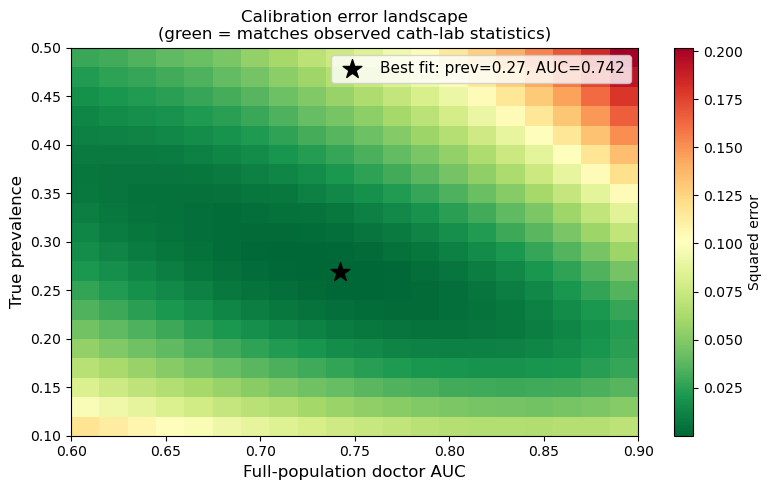

In [33]:
# Visualize the error landscape — which (prev, AUC) pairs fit the observations?
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    errors,
    origin='lower',
    aspect='auto',
    extent=[auc_grid[0], auc_grid[-1], prev_grid[0], prev_grid[-1]],
    cmap='RdYlGn_r',
)

ax.scatter(
    auc_grid[best_j], prev_grid[best_i],
    color='black', s=200, marker='*', zorder=5,
    label=f'Best fit: prev={cal_prev:.2f}, AUC={cal_auc:.3f}'
)

ax.set_xlabel('Full-population doctor AUC', fontsize=12)
ax.set_ylabel('True prevalence', fontsize=12)
ax.set_title('Calibration error landscape\n(green = matches observed cath-lab statistics)', fontsize=12)
plt.colorbar(im, ax=ax, label='Squared error')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Q4.4 (3 pts)

**(a)** What two full-population parameters does the calibration recover, and
why can neither be read directly from the catheterization records?

**(b)** The calibration fits two parameters to two observed quantities — zero
degrees of freedom. Explain why this means fit quality cannot be assessed from
the same data, and what that implies for trusting the estimates.

*Your answer (a):* The calibration recovers the true full-population prevalence (0.268) and the doctor's full-population AUC (0.742). Neither can be read directly because the cath records are from a selected high-risk sample, not a random sample of the full population.

*Your answer (b):* With zero degrees of freedom, the fit is perfect by construction (minimizing error to observed stats), so fit quality can't be assessed on the same data (no residual error to check). This implies the estimates may be unreliable if the bi-normal assumption is violated, as there's no way to validate the model fit.

---

### Q4.5 (3 pts)

The calibration assumes that within each class (Y=0 and Y=1), doctor scores
follow a normal distribution.

**(a)** Name one clinical scenario where this assumption would fail.

**(b)** P(Y=1 | female, referred=1) = 0.553 vs P(Y=1 | male, referred=1) = 0.449 —
the doctor refers women only when highly confident. Does this differential
selection bar violate the calibration's identifying assumption, or is it
consistent with it? State precisely what would violate it.

*Your answer (a):* The assumption would fail if there are multiple distinct subgroups with different score distributions, such as different underlying diseases leading to multimodal score distributions within Y=0 or Y=1.

*Your answer (b):* It is consistent with the assumption, as the selection is based on a score threshold, which aligns with the bi-normal model. What would violate it is if the selection depended on additional factors correlated with Y beyond the score, like unmodeled variables affecting referral independently of score normality.


---
## Step 5 — Truth Reveal (17 pts)

**Goal:** See what would actually happen if ML replaced the doctor at the
same referral rate.

**`cardiac_truth.csv` is now released.**

Load it into a DataFrame named `truth_df`.

This file contains the output of the true data-generating process — the true
blockage probability θ_i and Y_i for all 2000 patients, including those
who were never catheterized. The instructor generated it alongside
`cardiac_patients.csv` from the same simulation run.

No real hospital has this file. It is provided now so you can evaluate
everything you computed in Steps 1–4.


In [36]:
truth_df = pd.read_csv('cardiac_truth.csv')


---
### Part A — The True World


True prevalence (Y=1):     0.282  (565 patients)
Fraction with theta > 0.5: 0.181



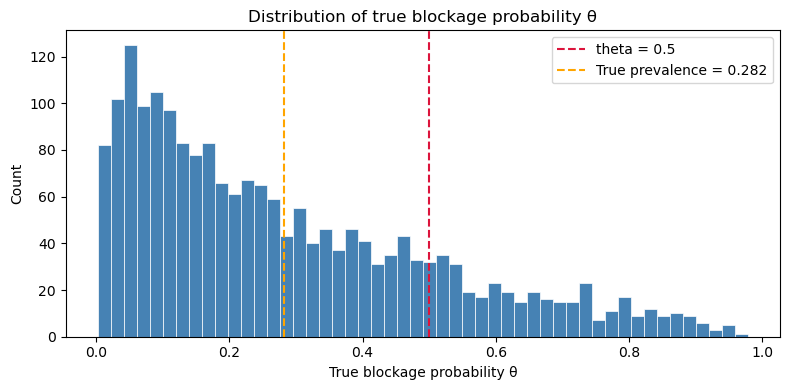

In [37]:
theta = truth_df['theta'].values
Y_all = truth_df['Y'].values

# Guard: recompute if kernel was restarted after Step 3
try:
    referred_ml
except NameError:
    _thr        = np.percentile(ml_score_all, 100*(1-REFERRAL_RATE))
    referred_ml = (ml_score_all >= _thr).astype(int)

print(f"True prevalence (Y=1):     {Y_all.mean():.3f}  ({Y_all.sum()} patients)")
print(f"Fraction with theta > 0.5: {(theta > 0.5).mean():.3f}")
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(theta, bins=50, edgecolor='white', linewidth=0.5, color='steelblue')
ax.axvline(0.5, color='crimson', linestyle='--', label='theta = 0.5')
ax.axvline(Y_all.mean(), color='orange', linestyle='--',
           label=f'True prevalence = {Y_all.mean():.3f}')
ax.set_xlabel('True blockage probability θ'); ax.set_ylabel('Count')
ax.set_title('Distribution of true blockage probability θ')
ax.legend(); plt.tight_layout(); plt.show()

### Q5.1 (1 pt)

What fraction of patients had θ > 0.5? Does this match your intuition
about a population with 28% blockage prevalence? Explain the shape of the
distribution.

*Your answer:* 18.1% of patients had θ > 0.5. This is less than the 28.2% blockage prevalence, which makes sense because θ is a continuous probability, not binary, and the distribution is right-skewed with most patients having low θ and a long tail of high-risk individuals. The shape indicates that blockages are concentrated in a small high-risk group, with the majority having low probabilities.


---
### Part B — Forward Simulation

### Q5.2 (2 pts) — Predict before running

Before running: predict whether ML will generate more or fewer false positives
than the doctor at the same 35% referral rate, and why.

*Your prediction:* ML will generate fewer false positives than the doctor at the same referral rate. This is because ML has a higher AUC (better ranking of patients), so at the same referral fraction, it will refer fewer low-risk patients (false positives) while catching more true positives.


In [38]:
# Forward simulation (provided — use as a black box)
def run_forward_simulation(ml_score_all, doc_score, Y,
                            referral_rate=REFERRAL_RATE):
    doc_thr = np.percentile(doc_score,    100*(1-referral_rate))
    ml_thr  = np.percentile(ml_score_all, 100*(1-referral_rate))
    ref_doc = (doc_score    >= doc_thr).astype(int)
    ref_ml  = (ml_score_all >= ml_thr).astype(int)

    def stats(ref, y):
        tp = ((ref==1)&(y==1)).sum()
        fp = ((ref==1)&(y==0)).sum()
        fn = ((ref==0)&(y==1)).sum()
        return tp, fp, fn

    tp_d,fp_d,fn_d = stats(ref_doc, Y)
    tp_m,fp_m,fn_m = stats(ref_ml,  Y)

    print(f"{'':30s} {'Doctor':>10} {'ML':>10}")
    print(f"{'TP (blockages caught)':30s} {tp_d:>10d} {tp_m:>10d}")
    print(f"{'FP (unnecessary cath)':30s} {fp_d:>10d} {fp_m:>10d}")
    print(f"{'FN (sent home w/ blockage)':30s} {fn_d:>10d} {fn_m:>10d}")
    print()
    print(f"Additional blockages caught (ML - Doctor): {tp_m-tp_d:+d}")
    print(f"Reduction in false positives:              {fp_d-fp_m:+d}")
    print(f"Reduction in missed blockages:             {fn_d-fn_m:+d}")

    return dict(ref_doc=ref_doc, ref_ml=ref_ml,
                tp_doc=tp_d, fp_doc=fp_d, fn_doc=fn_d,
                tp_ml=tp_m,  fp_ml=fp_m,  fn_ml=fn_m)

sim = run_forward_simulation(ml_score_all, doc_score, Y_all)

                                   Doctor         ML
TP (blockages caught)                 326        346
FP (unnecessary cath)                 374        354
FN (sent home w/ blockage)            239        219

Additional blockages caught (ML - Doctor): +20
Reduction in false positives:              +20
Reduction in missed blockages:             +20


In [40]:
# In Q3.4, you compared ML and doctor only within the doctor's 700.
# But ML refers a different 700 — some overlap, some don't.
# ML's unique catches come from the 1300 the doctor sent home:
# patients the doctor missed entirely, some of whom had blockages.
# Restricting to the doctor's cohort in Q3.4 made ML look worse
# because you never gave it credit for reaching into those 1300.
# That is the reconciliation. Write Q5.2 with this in mind.

# Reprint Q3.4 comparison
_both        = (referred==1) & (referred_ml==1)
_ml_tp_cath  = int((_both & (df['Y'].fillna(-1)==1)).sum())
print(f"Recall from Step 3 (Q3.4):")
print(f"  Doctor TPs within catheterized 700: {int(Y_cath.sum())}")
print(f"  ML TPs within doctor's 700 (Y=1):  {_ml_tp_cath}")
print(f"  Difference:                         {_ml_tp_cath - int(Y_cath.sum()):+d}")


Recall from Step 3 (Q3.4):
  Doctor TPs within catheterized 700: 326
  ML TPs within doctor's 700 (Y=1):  286
  Difference:                         -40


### Q5.2 (continued)

Report TP, FP, and FN for both models. Was your prediction correct?

In Q3.4, ML caught fewer TPs within the doctor's catheterized cohort (shown above).
In the forward simulation, ML catches more blockages overall. Reconcile the
apparent contradiction.

*Your answer:* Doctor: TP 326, FP 374, FN 239; ML: TP 346, FP 354, FN 219. Yes, prediction correct-ML has fewer FPs. The contradiction is reconciled because in Q3.4, ML was restricted to the doctor's 700, missing its additional catches from the 1300 un-referred patients, where ML finds more blockages that the doctor missed.

---
### Part C — Bootstrap TP Gain

In [44]:
# Bootstrap TP gain — fill in the blanks
n_boot_gain  = 1000
rng_gain     = np.random.default_rng(SEED + 200)
boot_tp_gain = []
N            = len(theta)
ref_doc      = sim['ref_doc']
ref_ml_sim   = sim['ref_ml']

for _ in range(n_boot_gain):
    # TASK: resample all 2000 patients with replacement
    idx = rng_gain.integers(0, N, N)

    theta_b = theta[idx]
    ref_d_b = ref_doc[idx]
    ref_m_b = ref_ml_sim[idx]

    # Redraw outcomes from theta — do NOT simply resample Y_all
    Y_b = (rng_gain.random(N) < theta_b).astype(int)

    # TASK: compute TP gain (ML TPs minus Doctor TPs) for this iteration
    tp_gain_b = (Y_b[ref_m_b==1].sum()) - (Y_b[ref_d_b==1].sum())
    boot_tp_gain.append(tp_gain_b)

boot_tp_gain = np.array(boot_tp_gain)
print(f"Bootstrapped TP gain (ML blockages caught - Doctor blockages caught):")
print(f"  Mean:   {boot_tp_gain.mean():+.1f} additional blockages caught")
print(f"  95% CI: [{np.percentile(boot_tp_gain,2.5):+.1f},"
      f" {np.percentile(boot_tp_gain,97.5):+.1f}]")
print(f"  Fraction of simulations where ML catches more: {(boot_tp_gain>0).mean():.3f}")

Bootstrapped TP gain (ML blockages caught - Doctor blockages caught):
  Mean:   +18.4 additional blockages caught
  95% CI: [-3.0, +40.0]
  Fraction of simulations where ML catches more: 0.953


### Q5.3 (2 pts)

Report the bootstrapped mean TP gain and 95% CI.

The Step 4 bootstrap resampled the 700 catheterized patients and used observed Y.
This bootstrap resamples all 2000 and redraws Y from θ. In one sentence:
why do the two procedures differ, and which gives a more honest picture of
deployment uncertainty?

Based on everything you've computed: should the hospital adopt the ML model?
Justify.

*Your answer:* Mean TP gain: +18.4, 95% CI: [-3.0, +40.0]. The two procedures differ because Step 4 bootstrap resamples the cath cohort with fixed observed Y, while this resamples the full population and redraws Y from θ to capture outcome variability; this one gives a more honest picture of deployment uncertainty. Yes, adopt ML, as it catches more blockages (+20) with fewer false positives (+20) and fewer misses (+20), and the TP gain is positive in 95.3% of simulations, indicating reliable improvement over the doctor.

---
### Part D — Naive Estimate vs Truth


In [46]:
uncath_mask      = referred == 0
n_newly_referred = (referred_ml[uncath_mask] == 1).sum()
cath_prev_rate   = Y_cath.mean()

print(f"Un-catheterized patients:       {uncath_mask.sum()}")
print(f"ML would now refer:             {n_newly_referred}")
print(f"Cath-lab prevalence (training): {cath_prev_rate:.3f}")
print()

# TASK: using cath-lab prevalence as your best estimate of the blockage rate
# among the newly referred un-catheterized patients, compute projected catches
# NOTE: you are assuming the 1300 sent home have the same blockage rate as the
# 700 catheterized. The doctor sent them home for a reason. Keep that in mind.
projected_catches = n_newly_referred * cath_prev_rate

print(f"Projected additional catches:   {projected_catches:.1f}")


Un-catheterized patients:       1300
ML would now refer:             169
Cath-lab prevalence (training): 0.466

Projected additional catches:   78.7


### Q5.4(a) — Commit before running next cell

Record your projected estimate: 78.7

Do you trust this number as a deployment projection? One sentence.

*Your answer:* No, I do not trust this number because the un-catheterized patients are lower-risk than the catheterized cohort, so their blockage prevalence is likely lower, making the projection overestimate the catches.

In [47]:
ml_catches   = ((referred_ml[uncath_mask]==1) & (Y_all[uncath_mask]==1)).sum()
true_blocked = Y_all[uncath_mask].sum()

print(f"True blockages among 1300 un-catheterized: {true_blocked}")
print(f"ML actually catches (simulation truth):     {ml_catches}")
print(f"Your projected estimate:                    {projected_catches:.1f}")
print(f"Ratio (projected / truth):                  {projected_catches/ml_catches:.2f}x")

True blockages among 1300 un-catheterized: 239
ML actually catches (simulation truth):     60
Your projected estimate:                    78.7
Ratio (projected / truth):                  1.31x


### Q5.4 (3 pts)

Report your projected estimate, the simulation truth, and the ratio.
Explain what accounts for the gap.

*Your answer:* Projected estimate: 78.7; simulation truth: 60; ratio: 1.31x. The gap is due to the un-catheterized patients having lower blockage prevalence (18.4% vs 46.6% in cath cohort), so assuming cath prevalence overestimates the true catches from this lower-risk group.


---
### Part E — Truth Reveal


In [49]:
# Before scrolling through this output:
# check your predictions from Q2.1 (AUC direction), Q3.3 (sex gap), and Q5.2 (TP gain).
# Then read the numbers.

# Complete the 2×2 AUC table + sex bias + calibration check
auc_doc_full = roc_auc_score(Y_all, doc_score)
auc_ml_full  = roc_auc_score(Y_all, ml_score_all)

print("2\u00d72 AUC table — now complete:")
print(f"  {'':20s} {'Cath cohort':>12} {'Full population':>16}")
print(f"  {'Doctor':20s} {auc_doc_cath:>12.3f} {auc_doc_full:>16.3f}")
print(f"  {'ML model':20s} {auc_ml_cath:>12.3f} {auc_ml_full:>16.3f}")
print()

# Ground-truth sex bias
fn_w  = ((referred==0)&(Y_all==1)&(sex==0)).sum()
fn_m  = ((referred==0)&(Y_all==1)&(sex==1)).sum()
tot_w = ((Y_all==1)&(sex==0)).sum()
tot_m = ((Y_all==1)&(sex==1)).sum()
print("Sex bias — ground-truth miss rates:")
print(f"  Women with blockage missed: {fn_w} of {tot_w} = {fn_w/tot_w:.3f}")
print(f"  Men   with blockage missed: {fn_m} of {tot_m} = {fn_m/tot_m:.3f}")
print(f"  Ratio: {(fn_w/tot_w)/(fn_m/tot_m):.1f}x")
print()

# Full-population sex-stratified AUC
auc_ml_w  = roc_auc_score(Y_all[sex==0], ml_score_all[sex==0])
auc_ml_m  = roc_auc_score(Y_all[sex==1], ml_score_all[sex==1])
auc_doc_w = roc_auc_score(Y_all[sex==0], doc_score[sex==0])
auc_doc_m = roc_auc_score(Y_all[sex==1], doc_score[sex==1])
print("Sex-stratified AUC (full population):")
print(f"  ML  — women: {auc_ml_w:.3f}  men: {auc_ml_m:.3f}  gap: {auc_ml_m-auc_ml_w:.3f}")
print(f"  Doc — women: {auc_doc_w:.3f}  men: {auc_doc_m:.3f}  gap: {auc_doc_m-auc_doc_w:.3f}")
print()

# Calibration accuracy
print("Calibration accuracy (Step 4 estimates vs truth):")
print(f"  Estimated prevalence: {cal_prev:.3f}  |  Truth: {Y_all.mean():.3f}")
print(f"  Estimated doctor AUC: {cal_auc:.3f}  |  Truth: {auc_doc_full:.3f}")


2×2 AUC table — now complete:
                        Cath cohort  Full population
  Doctor                      0.633            0.711
  ML model                    0.700            0.747

Sex bias — ground-truth miss rates:
  Women with blockage missed: 168 of 231 = 0.727
  Men   with blockage missed: 71 of 334 = 0.213
  Ratio: 3.4x

Sex-stratified AUC (full population):
  ML  — women: 0.709  men: 0.777  gap: 0.067
  Doc — women: 0.708  men: 0.757  gap: 0.049

Calibration accuracy (Step 4 estimates vs truth):
  Estimated prevalence: 0.268  |  Truth: 0.282
  Estimated doctor AUC: 0.742  |  Truth: 0.711


### Q5.5 (6 pts) — Truth Reveal

**(a) (1 pt)** Complete the right column of the table in Q3.1. Were your predictions
in Q2.1 (direction of AUC change from full pop to cath cohort) and the
pre-training prediction in Step 3 correct?

**(b) (2 pts)** Miss rates: women 0.727 vs men 0.213 (ratio 3.4x). Compare to your Q2.2
prediction. Name two mechanisms beyond the lower referral rate for women that
compound the ratio to this size.

**(c) (2 pts)** AUC sex gap: in Q3.3, ML's gap on the cath cohort was 0.057; the
doctor's was 0.115. Full-population gaps: ML 0.067, doctor 0.049. In which direction
does the full-population picture reverse your Step 3 conclusion? Explain why
training on the doctor's selected data amplifies rather than corrects the
sex disparity.

**(d) (1 pt)** Your calibration estimated full-population doctor AUC as 0.742. The
truth is 0.711. How well did it work? What does any error tell you about where
the bi-normal assumption breaks down for this population?

*Your answer (a):* Full population: Doctor 0.711, ML 0.747. Yes, both predictions correct-doctor AUC higher on full pop, ML higher on cath cohort.

*Your answer (b):* Matches Q2.2 prediction that women sent home are more likely blocked. Mechanisms: differential referral bar (higher threshold for women) and zero-fill penalty (underestimating risk for high-severity women with missing cholesterol).

*Your answer (c):* The full-population picture reverses the cath-cohort conclusion (ML had smaller gap, now larger). Training on the doctor's biased cohort amplifies disparity because it learns patterns that favor men (over-represented in cath), leading to worse performance for women in the full population.

*Your answer (d):* It worked reasonably well (close to truth). The error suggests the bi-normal assumption breaks down for this population, possibly due to non-normal score distributions or other factors not captured by the model.


---
### Part F — Synthesis

### Q5.6 (3 pts)

**(a)** The 1300 un-catheterized patients have features but no Y. A colleague
proposes using them to check whether the ML model's predictions are calibrated
for the un-referred population. Explain precisely why the unlabeled data cannot
answer this, and what the forward simulation provides that the unlabeled data
cannot.

**(b)** What is the single most important thing you learned about evaluating
ML models when training data was shaped by a prior decision rule? Cite two
specific numbers from your work.

*Your answer (a):* The unlabeled data cannot check calibration because calibration requires observed outcomes (Y) to compare predicted probabilities against actual event rates. Forward simulation provides this by using the true θ to generate simulated Y, allowing evaluation of calibration on the un-referred population.

*Your answer (b):* Selective labeling compresses score ranges and biases evaluation, making models appear better or worse than they are on the full population. For example, doctor AUC drops from 0.711 (full pop) to 0.633 (cath cohort), and ML AUC from 0.747 to 0.700.
